In [ ]:
import os
import shutil

# Remove a pasta /content/drive com tudo dentro
if os.path.exists('/content/drive'):
    shutil.rmtree('/content/drive', ignore_errors=True)
    print("✅ Pasta /content/drive removida.")
else:
    print("⚠️ Pasta /content/drive não existia.")

# Recria a pasta vazia
os.makedirs('/content/drive', exist_ok=True)
print("✅ Pasta /content/drive recriada vazia.")

✅ Pasta /content/drive removida.
✅ Pasta /content/drive recriada vazia.


In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [ ]:
!ls "/content/drive/MyDrive"

 ATT00001.pdf					 'Proposta de projeto.gdoc'
 best_model.pth					  reconstrucao_3d_correta.obj
'Colab Notebooks'				  reconstrucao_3d_escala.obj
 dice_curve.png					  reconstrucao_3d.obj
 hvp_segmented					  segmentation_results.png
 hvp_training					  training_curves.png
 IMG_20231209_150124.jpg			  training_history.csv
 IMG_20231209_150130.jpg			  training_history.txt
 IMG_20231209_150148.jpg			  train_losses.npy
 IMG_20231209_150153.jpg			  unet2_hvp_final.keras
 IMG_20231209_150159.jpg			  unet_training_history.csv
 IMG_20231209_150216.jpg			  unet_visible_best.h5
'Luciana Roncarati INTELIG-NCIA ARTIFICIAL.pdf'   unet_visible_best.keras
 Luciana_sintatica_semantica.gdoc		  val_dices.npy
 postacert.eml					  val_losses.npy
'Proposta de orçamento.gdoc'


In [ ]:
base = "/content/drive/MyDrive/hvp_training"
print("Conteúdo de hvp_training/train:")
!ls -la "$base/train"

print("\nConteúdo de hvp_training/val:")
!ls -la "$base/val"

Conteúdo de hvp_training/train:
total 8
drwx------ 2 root root 4096 May  1 18:07 images
drwx------ 2 root root 4096 May 18 01:30 masks

Conteúdo de hvp_training/val:
total 8
drwx------ 2 root root 4096 May  1 18:07 images
drwx------ 2 root root 4096 May 18 01:30 masks


In [ ]:
import os
import cv2
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
import matplotlib.pyplot as plt
from tqdm import tqdm
import random

In [ ]:
base = "/content/drive/MyDrive/hvp_training"
train_imgs = os.path.join(base, "train", "images")
train_masks = os.path.join(base, "train", "masks")
val_imgs = os.path.join(base, "val", "images")
val_masks = os.path.join(base, "val", "masks")

print("Treino imagens:", train_imgs)
print("Treino máscaras:", train_masks)
print("Val imagens:", val_imgs)
print("Val máscaras:", val_masks)

Treino imagens: /content/drive/MyDrive/hvp_training/train/images
Treino máscaras: /content/drive/MyDrive/hvp_training/train/masks
Val imagens: /content/drive/MyDrive/hvp_training/val/images
Val máscaras: /content/drive/MyDrive/hvp_training/val/masks


In [ ]:
def listar_pares(imgs_dir, masks_dir):
    pares = []
    for f in os.listdir(imgs_dir):
        if f.lower().endswith(('.png', '.jpg', '.jpeg')):
            base_name = os.path.splitext(f)[0]
            mask_file = base_name + '.png'
            if os.path.exists(os.path.join(masks_dir, mask_file)):
                pares.append(f)
    return pares

train_files = listar_pares(train_imgs, train_masks)
val_files = listar_pares(val_imgs, val_masks)

print(f"Treino: {len(train_files)} pares")
print(f"Validação: {len(val_files)} pares")

Treino: 246 pares
Validação: 62 pares


In [ ]:
IMG_HEIGHT, IMG_WIDTH = 512, 512
BATCH_SIZE = 4   # seguro para 512x512 no Colab (com T4)

def load_image_mask(img_path, mask_path):
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (IMG_WIDTH, IMG_HEIGHT)) / 255.0

    mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
    mask = cv2.resize(mask, (IMG_WIDTH, IMG_HEIGHT), interpolation=cv2.INTER_NEAREST)
    mask = (mask > 127).astype(np.float32)[..., np.newaxis]
    return img, mask

def data_generator(file_list, imgs_dir, masks_dir, augment=False):
    while True:
        random.shuffle(file_list)
        for i in range(0, len(file_list), BATCH_SIZE):
            batch_files = file_list[i:i+BATCH_SIZE]
            imgs, masks = [], []
            for fname in batch_files:
                img_path = os.path.join(imgs_dir, fname)
                mask_path = os.path.join(masks_dir, os.path.splitext(fname)[0] + '.png')
                img, mask = load_image_mask(img_path, mask_path)
                if augment and random.random() > 0.5:
                    img = np.fliplr(img).copy()
                    mask = np.fliplr(mask).copy()
                imgs.append(img)
                masks.append(mask)
            yield np.array(imgs, dtype=np.float32), np.array(masks, dtype=np.float32)

train_gen = data_generator(train_files, train_imgs, train_masks, augment=True)
val_gen = data_generator(val_files, val_imgs, val_masks, augment=False)

steps_per_epoch = max(1, len(train_files) // BATCH_SIZE)
validation_steps = max(1, len(val_files) // BATCH_SIZE)

In [ ]:
def dice_coef(y_true, y_pred, smooth=1e-6):
    y_pred = tf.cast(y_pred > 0.5, tf.float32)
    intersection = tf.reduce_sum(y_true * y_pred)
    union = tf.reduce_sum(y_true) + tf.reduce_sum(y_pred)
    return (2. * intersection + smooth) / (union + smooth)

def dice_loss(y_true, y_pred):
    return 1 - dice_coef(y_true, y_pred)

def combined_loss(y_true, y_pred, alpha=0.5):
    bce = tf.keras.losses.binary_crossentropy(y_true, y_pred)
    dice = dice_loss(y_true, y_pred)
    return alpha * bce + (1 - alpha) * dice

def iou_score(y_true, y_pred):
    y_pred = tf.cast(y_pred > 0.5, tf.float32)
    intersection = tf.reduce_sum(y_true * y_pred)
    union = tf.reduce_sum(y_true) + tf.reduce_sum(y_pred) - intersection
    return (intersection + 1e-6) / (union + 1e-6)

In [ ]:
def conv_block(x, filters, dropout_rate=0.1):
    x = layers.Conv2D(filters, 3, padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Conv2D(filters, 3, padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    if dropout_rate:
        x = layers.Dropout(dropout_rate)(x)
    return x

def unet_model(input_size=(IMG_HEIGHT, IMG_WIDTH, 3)):
    inputs = layers.Input(input_size)

    c1 = conv_block(inputs, 64, dropout_rate=0.1)
    p1 = layers.MaxPooling2D((2,2))(c1)

    c2 = conv_block(p1, 128, dropout_rate=0.1)
    p2 = layers.MaxPooling2D((2,2))(c2)

    c3 = conv_block(p2, 256, dropout_rate=0.2)
    p3 = layers.MaxPooling2D((2,2))(c3)

    c4 = conv_block(p3, 512, dropout_rate=0.2)
    p4 = layers.MaxPooling2D((2,2))(c4)

    c5 = conv_block(p4, 1024, dropout_rate=0.3)

    u6 = layers.Conv2DTranspose(512, (2,2), strides=(2,2), padding='same')(c5)
    u6 = layers.concatenate([u6, c4])
    c6 = conv_block(u6, 512, dropout_rate=0.2)

    u7 = layers.Conv2DTranspose(256, (2,2), strides=(2,2), padding='same')(c6)
    u7 = layers.concatenate([u7, c3])
    c7 = conv_block(u7, 256, dropout_rate=0.2)

    u8 = layers.Conv2DTranspose(128, (2,2), strides=(2,2), padding='same')(c7)
    u8 = layers.concatenate([u8, c2])
    c8 = conv_block(u8, 128, dropout_rate=0.1)

    u9 = layers.Conv2DTranspose(64, (2,2), strides=(2,2), padding='same')(c8)
    u9 = layers.concatenate([u9, c1])
    c9 = conv_block(u9, 64, dropout_rate=0.1)

    outputs = layers.Conv2D(1, (1,1), activation='sigmoid')(c9)
    return Model(inputs, outputs)

model = unet_model()
model.compile(optimizer='adam', loss=combined_loss, metrics=['accuracy', dice_coef, iou_score])
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 512, 512,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 512, 512,  │      1,792 │ input_layer[0][0] │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 512, 512,  │        256 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 512, 512,  │     36,928 │ batch_normalizat… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 512, 512,  │        256 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 512, 512,  │          0 │ batch_normalizat… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 256, 256,  │          0 │ dropout[0][0]     │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 256, 256,  │     73,856 │ max_pooling2d[0]… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 256, 256,  │        512 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 256, 256,  │    147,584 │ batch_normalizat… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 256, 256,  │        512 │ conv2d_3[0][0]    │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 256, 256,  │          0 │ batch_normalizat… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 128, 128,  │          0 │ dropout_1[0][0]   │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 128, 128,  │    295,168 │ max_pooling2d_1[… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 128,  │      1,024 │ conv2d_4[0][0]    │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 128, 128,  │    590,080 │ batch_normalizat… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 128,  │      1,024 │ conv2d_5[0][0]  

 Total params: 31,055,297 (118.47 MB)

 Trainable params: 31,043,521 (118.42 MB)

 Non-trainable params: 11,776 (46.00 KB)

salva o melhor modelo

In [ ]:
checkpoint = ModelCheckpoint(
    filepath=os.path.join(base, "melhor_modelo_unet_512.h5"),
    monitor='val_dice_coef',
    mode='max',
    save_best_only=True,
    verbose=1
)

early_stop = EarlyStopping(
    monitor='val_dice_coef',
    mode='max',
    patience=15,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,
    patience=5,
    min_lr=1e-7,
    verbose=1
)

callbacks = [checkpoint, early_stop, reduce_lr]

training

In [ ]:
EPOCHS = 60
history = model.fit(
    train_gen,
    steps_per_epoch=steps_per_epoch,
    validation_data=val_gen,
    validation_steps=validation_steps,
    epochs=EPOCHS,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/60
61/61 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.9132 - dice_coef: 0.8767 - iou_score: 0.8157 - loss: 0.1632
Epoch 1: val_dice_coef improved from None to 0.45337, saving model to /content/drive/MyDrive/hvp_training/melhor_modelo_unet_512.h5



Epoch 1: finished saving model to /content/drive/MyDrive/hvp_training/melhor_modelo_unet_512.h5
61/61 ━━━━━━━━━━━━━━━━━━━━ 459s 6s/step - accuracy: 0.9549 - dice_coef: 0.9283 - iou_score: 0.8753 - loss: 0.0934 - val_accuracy: 0.2968 - val_dice_coef: 0.4534 - val_iou_score: 0.2968 - val_loss: 73.9956 - learning_rate: 0.0010
Epoch 2/60
61/61 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9717 - dice_coef: 0.9503 - iou_score: 0.9061 - loss: 0.0640
Epoch 2: val_dice_coef improved from 0.45337 to 0.46558, saving model to /content/drive/MyDrive/hvp_training/melhor_modelo_unet_512.h5



Epoch 2: finished saving model to /content/drive/MyDrive/hvp_training/melhor_modelo_unet_512.h5
61/61 ━━━━━━━━━━━━━━━━━━━━ 137s 1s/step - accuracy: 0.9718 - dice_coef: 0.9504 - iou_score: 0.9063 - loss: 0.0618 - val_accuracy: 0.3231 - val_dice_coef: 0.4656 - val_iou_score: 0.3057 - val_loss: 1.1038 - learning_rate: 0.0010
Epoch 3/60
61/61 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9687 - dice_coef: 0.9467 - iou_score: 0.8996 - loss: 0.0670
Epoch 3: val_dice_coef did not improve from 0.46558
61/61 ━━━━━━━━━━━━━━━━━━━━ 74s 1s/step - accuracy: 0.9708 - dice_coef: 0.9497 - iou_score: 0.9047 - loss: 0.0624 - val_accuracy: 0.3252 - val_dice_coef: 0.4583 - val_iou_score: 0.3013 - val_loss: 0.6932 - learning_rate: 0.0010
Epoch 4/60
61/61 ━━━━━━━━━━━━━━━━━━━━ 0s 978ms/step - accuracy: 0.9766 - dice_coef: 0.9590 - iou_score: 0.9214 - loss: 0.0488
Epoch 4: val_dice_coef improved from 0.46558 to 0.89827, saving model to /content/drive/MyDrive/hvp_training/melhor_modelo_unet_512.h5



Epoch 4: finished saving model to /content/drive/MyDrive/hvp_training/melhor_modelo_unet_512.h5
61/61 ━━━━━━━━━━━━━━━━━━━━ 87s 1s/step - accuracy: 0.9757 - dice_coef: 0.9584 - iou_score: 0.9205 - loss: 0.0488 - val_accuracy: 0.9347 - val_dice_coef: 0.8983 - val_iou_score: 0.8158 - val_loss: 0.3381 - learning_rate: 0.0010
Epoch 5/60
61/61 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9735 - dice_coef: 0.9533 - iou_score: 0.9114 - loss: 0.0543
Epoch 5: val_dice_coef did not improve from 0.89827
61/61 ━━━━━━━━━━━━━━━━━━━━ 75s 1s/step - accuracy: 0.9727 - dice_coef: 0.9506 - iou_score: 0.9068 - loss: 0.0587 - val_accuracy: 0.9241 - val_dice_coef: 0.8853 - val_iou_score: 0.7952 - val_loss: 0.2272 - learning_rate: 0.0010
Epoch 6/60
61/61 ━━━━━━━━━━━━━━━━━━━━ 0s 979ms/step - accuracy: 0.9739 - dice_coef: 0.9556 - iou_score: 0.9153 - loss: 0.0538
Epoch 6: val_dice_coef improved from 0.89827 to 0.94263, saving model to /content/drive/MyDrive/hvp_training/melhor_modelo_unet_512.h5



Epoch 6: finished saving model to /content/drive/MyDrive/hvp_training/melhor_modelo_unet_512.h5
61/61 ━━━━━━━━━━━━━━━━━━━━ 90s 1s/step - accuracy: 0.9745 - dice_coef: 0.9562 - iou_score: 0.9163 - loss: 0.0520 - val_accuracy: 0.9633 - val_dice_coef: 0.9426 - val_iou_score: 0.8916 - val_loss: 0.1847 - learning_rate: 0.0010
Epoch 7/60
61/61 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9750 - dice_coef: 0.9568 - iou_score: 0.9181 - loss: 0.0488
Epoch 7: val_dice_coef did not improve from 0.94263
61/61 ━━━━━━━━━━━━━━━━━━━━ 71s 1s/step - accuracy: 0.9749 - dice_coef: 0.9552 - iou_score: 0.9154 - loss: 0.0507 - val_accuracy: 0.9551 - val_dice_coef: 0.9218 - val_iou_score: 0.8552 - val_loss: 0.1552 - learning_rate: 0.0010
Epoch 8/60
61/61 ━━━━━━━━━━━━━━━━━━━━ 0s 982ms/step - accuracy: 0.9769 - dice_coef: 0.9577 - iou_score: 0.9193 - loss: 0.0484
Epoch 8: val_dice_coef did not improve from 0.94263
61/61 ━━━━━━━━━━━━━━━━━━━━ 67s 1s/step - accuracy: 0.9769 - dice_coef: 0.9596 - iou_score: 0.922


Epoch 9: finished saving model to /content/drive/MyDrive/hvp_training/melhor_modelo_unet_512.h5
61/61 ━━━━━━━━━━━━━━━━━━━━ 71s 1s/step - accuracy: 0.9762 - dice_coef: 0.9569 - iou_score: 0.9184 - loss: 0.0487 - val_accuracy: 0.9660 - val_dice_coef: 0.9429 - val_iou_score: 0.8923 - val_loss: 0.0751 - learning_rate: 0.0010
Epoch 10/60
61/61 ━━━━━━━━━━━━━━━━━━━━ 0s 991ms/step - accuracy: 0.9785 - dice_coef: 0.9598 - iou_score: 0.9233 - loss: 0.0450
Epoch 10: val_dice_coef improved from 0.94286 to 0.94639, saving model to /content/drive/MyDrive/hvp_training/melhor_modelo_unet_512.h5



Epoch 10: finished saving model to /content/drive/MyDrive/hvp_training/melhor_modelo_unet_512.h5
61/61 ━━━━━━━━━━━━━━━━━━━━ 76s 1s/step - accuracy: 0.9786 - dice_coef: 0.9610 - iou_score: 0.9256 - loss: 0.0448 - val_accuracy: 0.9715 - val_dice_coef: 0.9464 - val_iou_score: 0.8984 - val_loss: 0.0897 - learning_rate: 0.0010
Epoch 11/60
61/61 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9829 - dice_coef: 0.9711 - iou_score: 0.9441 - loss: 0.0367
Epoch 11: val_dice_coef improved from 0.94639 to 0.96875, saving model to /content/drive/MyDrive/hvp_training/melhor_modelo_unet_512.h5



Epoch 11: finished saving model to /content/drive/MyDrive/hvp_training/melhor_modelo_unet_512.h5
61/61 ━━━━━━━━━━━━━━━━━━━━ 77s 1s/step - accuracy: 0.9819 - dice_coef: 0.9689 - iou_score: 0.9400 - loss: 0.0378 - val_accuracy: 0.9810 - val_dice_coef: 0.9688 - val_iou_score: 0.9396 - val_loss: 0.0402 - learning_rate: 0.0010
Epoch 12/60
61/61 ━━━━━━━━━━━━━━━━━━━━ 0s 998ms/step - accuracy: 0.9831 - dice_coef: 0.9703 - iou_score: 0.9426 - loss: 0.0359
Epoch 12: val_dice_coef did not improve from 0.96875
61/61 ━━━━━━━━━━━━━━━━━━━━ 67s 1s/step - accuracy: 0.9842 - dice_coef: 0.9724 - iou_score: 0.9465 - loss: 0.0337 - val_accuracy: 0.9821 - val_dice_coef: 0.9639 - val_iou_score: 0.9306 - val_loss: 0.0401 - learning_rate: 0.0010
Epoch 13/60
61/61 ━━━━━━━━━━━━━━━━━━━━ 0s 974ms/step - accuracy: 0.9851 - dice_coef: 0.9726 - iou_score: 0.9478 - loss: 0.0326
Epoch 13: val_dice_coef did not improve from 0.96875
61/61 ━━━━━━━━━━━━━━━━━━━━ 67s 1s/step - accuracy: 0.9848 - dice_coef: 0.9714 - iou_scor


Epoch 14: finished saving model to /content/drive/MyDrive/hvp_training/melhor_modelo_unet_512.h5
61/61 ━━━━━━━━━━━━━━━━━━━━ 74s 1s/step - accuracy: 0.9867 - dice_coef: 0.9764 - iou_score: 0.9540 - loss: 0.0281 - val_accuracy: 0.9868 - val_dice_coef: 0.9775 - val_iou_score: 0.9560 - val_loss: 0.0292 - learning_rate: 0.0010
Epoch 15/60
61/61 ━━━━━━━━━━━━━━━━━━━━ 0s 997ms/step - accuracy: 0.9871 - dice_coef: 0.9788 - iou_score: 0.9585 - loss: 0.0269
Epoch 15: val_dice_coef did not improve from 0.97745
61/61 ━━━━━━━━━━━━━━━━━━━━ 68s 1s/step - accuracy: 0.9871 - dice_coef: 0.9776 - iou_score: 0.9563 - loss: 0.0277 - val_accuracy: 0.9787 - val_dice_coef: 0.9634 - val_iou_score: 0.9294 - val_loss: 0.0483 - learning_rate: 0.0010
Epoch 16/60
61/61 ━━━━━━━━━━━━━━━━━━━━ 0s 980ms/step - accuracy: 0.9869 - dice_coef: 0.9788 - iou_score: 0.9586 - loss: 0.0262
Epoch 16: val_dice_coef did not improve from 0.97745
61/61 ━━━━━━━━━━━━━━━━━━━━ 67s 1s/step - accuracy: 0.9876 - dice_coef: 0.9794 - iou_scor


Epoch 24: finished saving model to /content/drive/MyDrive/hvp_training/melhor_modelo_unet_512.h5
61/61 ━━━━━━━━━━━━━━━━━━━━ 75s 1s/step - accuracy: 0.9876 - dice_coef: 0.9783 - iou_score: 0.9576 - loss: 0.0263 - val_accuracy: 0.9877 - val_dice_coef: 0.9796 - val_iou_score: 0.9601 - val_loss: 0.0251 - learning_rate: 2.0000e-04
Epoch 25/60
61/61 ━━━━━━━━━━━━━━━━━━━━ 0s 995ms/step - accuracy: 0.9889 - dice_coef: 0.9800 - iou_score: 0.9608 - loss: 0.0240
Epoch 25: val_dice_coef did not improve from 0.97962
61/61 ━━━━━━━━━━━━━━━━━━━━ 67s 1s/step - accuracy: 0.9891 - dice_coef: 0.9804 - iou_score: 0.9616 - loss: 0.0236 - val_accuracy: 0.9855 - val_dice_coef: 0.9735 - val_iou_score: 0.9486 - val_loss: 0.0327 - learning_rate: 2.0000e-04
Epoch 26/60
61/61 ━━━━━━━━━━━━━━━━━━━━ 0s 981ms/step - accuracy: 0.9884 - dice_coef: 0.9810 - iou_score: 0.9628 - loss: 0.0235
Epoch 26: val_dice_coef did not improve from 0.97962
61/61 ━━━━━━━━━━━━━━━━━━━━ 67s 1s/step - accuracy: 0.9887 - dice_coef: 0.9810 - 

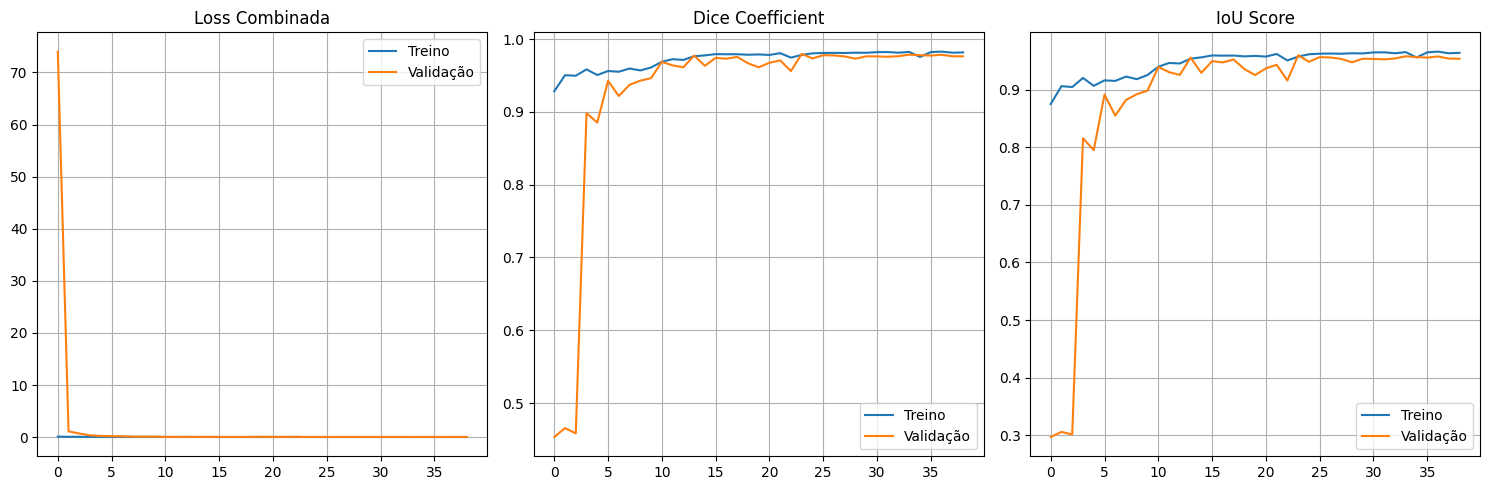

Melhor Dice de validação: 0.9796203374862671


In [ ]:
plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
plt.plot(history.history['loss'], label='Treino')
plt.plot(history.history['val_loss'], label='Validação')
plt.title('Loss Combinada')
plt.legend()
plt.grid()

plt.subplot(1,3,2)
plt.plot(history.history['dice_coef'], label='Treino')
plt.plot(history.history['val_dice_coef'], label='Validação')
plt.title('Dice Coefficient')
plt.legend()
plt.grid()

plt.subplot(1,3,3)
plt.plot(history.history['iou_score'], label='Treino')
plt.plot(history.history['val_iou_score'], label='Validação')
plt.title('IoU Score')
plt.legend()
plt.grid()

plt.tight_layout()
plt.savefig(os.path.join(base, "historico_treinamento_512.png"))
plt.show()

print("Melhor Dice de validação:", max(history.history['val_dice_coef']))

1/1 ━━━━━━━━━━━━━━━━━━━━ 10s 10s/step


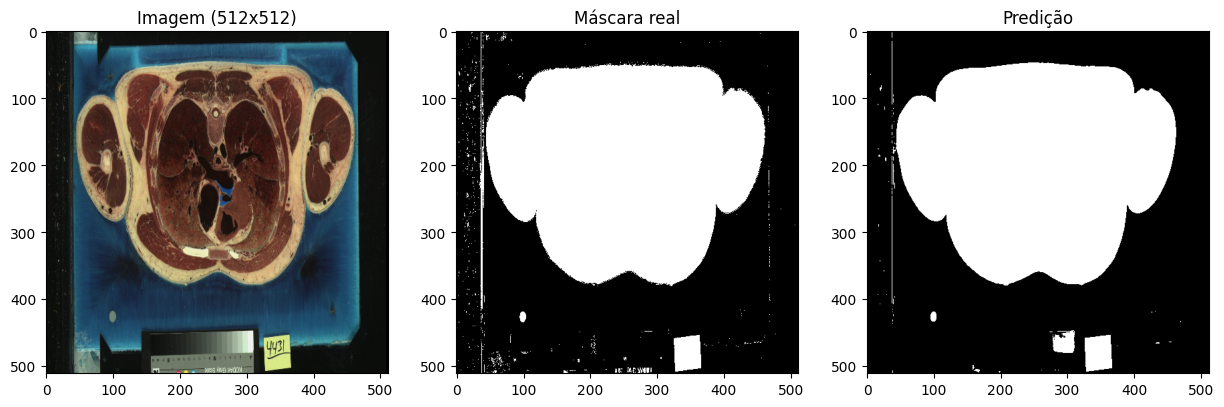

In [ ]:
from tensorflow.keras.models import load_model

modelo_final = load_model(os.path.join(base, "melhor_modelo_unet_512.h5"),
                          custom_objects={'combined_loss': combined_loss,
                                          'dice_coef': dice_coef,
                                          'iou_score': iou_score})

test_file = val_files[0]
img_path = os.path.join(val_imgs, test_file)
mask_path = os.path.join(val_masks, os.path.splitext(test_file)[0] + '.png')

img = cv2.cvtColor(cv2.imread(img_path), cv2.COLOR_BGR2RGB)
mask_true = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE) > 127

img_resized = cv2.resize(img, (IMG_WIDTH, IMG_HEIGHT)) / 255.0
mask_resized = cv2.resize(mask_true.astype(np.uint8), (IMG_WIDTH, IMG_HEIGHT), interpolation=cv2.INTER_NEAREST)

pred = modelo_final.predict(np.expand_dims(img_resized, axis=0))[0, :, :, 0]
pred_bin = pred > 0.5

fig, ax = plt.subplots(1,3, figsize=(15,5))
ax[0].imshow(img_resized)
ax[0].set_title("Imagem (512x512)")
ax[1].imshow(mask_resized, cmap='gray')
ax[1].set_title("Máscara real")
ax[2].imshow(pred_bin, cmap='gray')
ax[2].set_title("Predição")
plt.show()

In [ ]:
from google.colab import files
import pandas as pd

# Save training history to CSV
history_df = pd.DataFrame(history.history)
history_csv_path = os.path.join(base, "metricas_treinamento.csv")
history_df.to_csv(history_csv_path, index=False)

files.download(os.path.join(base, "melhor_modelo_unet_512.h5"))
files.download(history_csv_path)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>